<a href="https://colab.research.google.com/github/kjesinthuyaUCLL/mbti-tune/blob/main/notebooks/MBTI_Playlist_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1: Mount Google Drive and Load Data

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score # added: classification metrics requirement
# from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score # added: classification metrics requirement
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = "/content/drive/My Drive/mbti_tune_data/"

# Load data
df = pd.read_csv(f"{DATA_PATH}/playlist_data.csv")
print(f"✅ Loaded {len(df)} playlists")

# Load feature names
with open(f"{DATA_PATH}/features.json", 'r') as f:
    feature_cols = json.load(f)

print(f"✅ Loaded {len(feature_cols)} features")

# Display basic stats
print(f"\n📊 Personality distribution:")
print(df['personality'].value_counts())

print(f"\n📊 Dimension balance:")
for dim in ['E', 'N', 'T', 'J']:
    print(f"   {dim}: {df[dim].mean()*100:.1f}%")

Mounted at /content/drive
✅ Loaded 4201 playlists
✅ Loaded 45 features

📊 Personality distribution:
personality
INTJ    307
ESTP    306
INFJ    304
ENTP    303
ENTJ    303
ENFP    302
ENFJ    302
ISTP    300
INTP    299
INFP    295
ISFP    295
ESFP    231
ISFJ    221
ISTJ    196
ESTJ    122
ESFJ    115
Name: count, dtype: int64

📊 Dimension balance:
   E: 47.2%
   N: 57.5%
   T: 50.8%
   J: 44.5%


In [2]:
# 2: Prepare Feature Matrix and Targets

# Handle any missing values
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

# Prepare X and y
X = df[feature_cols].values.astype(np.float32)
y = df[['E', 'N', 'T', 'J']].values.astype(np.float32)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Train/val/test split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=df['personality']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=df[df.index.isin(range(len(X_temp)))]['personality'].values[:len(X_temp)]
)

print(f"\n📊 Split sizes:")
print(f"   Train: {len(X_train)}")
print(f"   Val:   {len(X_val)}")
print(f"   Test:  {len(X_test)}")

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print(f"\n✅ Data ready for training")

X shape: (4201, 45)
y shape: (4201, 4)

📊 Split sizes:
   Train: 2940
   Val:   630
   Test:  631

✅ Data ready for training


In [3]:
# 3: Neural Network Architecture

class MBTINetwork(nn.Module):
    """
    Deep Neural Network for MBTI dimension prediction
    Input: 45 audio features (means + stds + key counts)
    Output: 4 dimensions (E, N, T, J) as percentages (0-1)
    """
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout_rates=[0.3, 0.3, 0.2]):
        super(MBTINetwork, self).__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim, dropout in zip(hidden_dims, dropout_rates):
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        # Output layer (no sigmoid - we'll use BCEWithLogitsLoss)
        layers.append(nn.Linear(prev_dim, 4))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create model
model = MBTINetwork(input_dim=X_train.shape[1])
model = model.to(device)

print(f"\n✅ Model created with {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"\nModel architecture:")
print(model)

Using device: cuda

✅ Model created with 16,804 parameters

Model architecture:
MBTINetwork(
  (network): Sequential(
    (0): Linear(in_features=45, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=4, bias=True)
  )
)


In [4]:
# 4: Calculate Class Weights for Imbalance

def calculate_class_weights(y_train):
    """Calculate positive class weights for each dimension"""
    weights = []
    for i in range(4):
        n_pos = y_train[:, i].sum().item()
        n_neg = len(y_train) - n_pos
        if n_pos > 0:
            weight = n_neg / n_pos
        else:
            weight = 1.0
        weights.append(weight)
    return torch.tensor(weights, device=device)

# Convert y_train to numpy for calculation
pos_weights = calculate_class_weights(y_train)
print(f"Positive class weights (E,N,T,J):")
print(f"  E: {pos_weights[0]:.3f} (imbalance factor)")
print(f"  N: {pos_weights[1]:.3f}")
print(f"  T: {pos_weights[2]:.3f}")
print(f"  J: {pos_weights[3]:.3f}")

# Create weighted loss function
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

Positive class weights (E,N,T,J):
  E: 1.118 (imbalance factor)
  N: 0.741
  T: 0.968
  J: 1.246


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 5: Training Loop

def train_model(model, X_train, y_train, X_val, y_val, epochs=300, batch_size=32, lr=0.001):
    """Train the neural network"""

    # Create data loaders
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = TensorDataset(X_val, y_val)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # Optimizer and scheduler
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=30, factor=0.5)

    # Tracking
    train_losses = []
    val_losses = []
    val_accuracies = []
    best_val_loss = float('inf')

    print("="*60)
    print("TRAINING STARTING")
    print("="*60)
    print(f"Epochs: {epochs} | Batch size: {batch_size} | Learning rate: {lr}")
    print("-"*60)

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation phase
        model.eval()
        val_loss = 0
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                val_loss += criterion(outputs, batch_y).item()

                # Convert to probabilities
                preds = torch.sigmoid(outputs)
                all_preds.append(preds.cpu())
                all_targets.append(batch_y.cpu())

        # Calculate metrics
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        all_preds = torch.cat(all_preds)
        all_targets = torch.cat(all_targets)

        # Accuracy: prediction within 15% of actual
        accuracy = (torch.abs(all_preds - all_targets) < 0.15).float().mean().item()
        val_accuracies.append(accuracy)

        # Learning rate scheduling
        scheduler.step(val_loss)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), '/content/best_model.pth')

        # Print progress
        if (epoch + 1) % 30 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Acc: {accuracy:.2%}")

    print("-"*60)
    print("✅ TRAINING COMPLETE")
    print(f"Best validation loss: {best_val_loss:.4f}")

    return train_losses, val_losses, val_accuracies

# Train the model
train_losses, val_losses, val_accuracies = train_model(
    model, X_train, y_train, X_val, y_val,
    epochs=300, batch_size=32, lr=0.001
)

TRAINING STARTING
Epochs: 300 | Batch size: 32 | Learning rate: 0.001
------------------------------------------------------------
Epoch  30/300 | Train Loss: 0.5603 | Val Loss: 0.5926 | Acc: 10.91%
Epoch  60/300 | Train Loss: 0.5301 | Val Loss: 0.6021 | Acc: 15.71%
Epoch  90/300 | Train Loss: 0.4961 | Val Loss: 0.6122 | Acc: 18.21%
Epoch 120/300 | Train Loss: 0.4902 | Val Loss: 0.6193 | Acc: 20.87%
Epoch 150/300 | Train Loss: 0.4853 | Val Loss: 0.6259 | Acc: 22.30%
Epoch 180/300 | Train Loss: 0.4761 | Val Loss: 0.6249 | Acc: 20.12%
Epoch 210/300 | Train Loss: 0.4697 | Val Loss: 0.6275 | Acc: 22.58%
Epoch 240/300 | Train Loss: 0.4734 | Val Loss: 0.6227 | Acc: 21.83%
Epoch 270/300 | Train Loss: 0.4744 | Val Loss: 0.6245 | Acc: 21.94%
Epoch 300/300 | Train Loss: 0.4738 | Val Loss: 0.6254 | Acc: 22.54%
------------------------------------------------------------
✅ TRAINING COMPLETE
Best validation loss: 0.5899


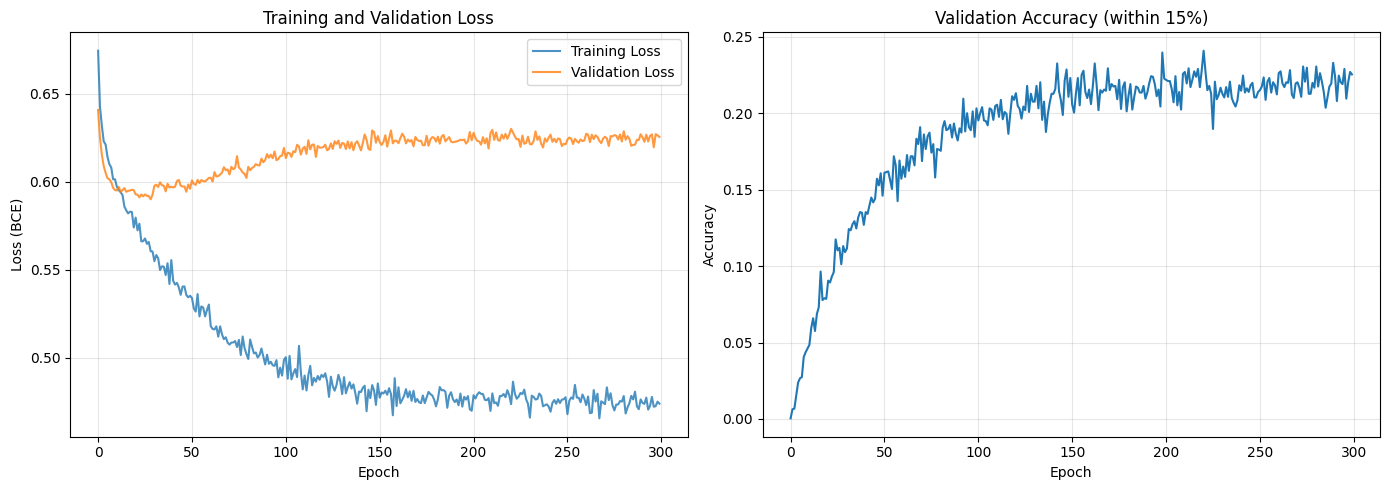

Final validation accuracy: 22.54%


In [6]:
# 6: Visualize Training Progress

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(train_losses, label='Training Loss', alpha=0.8)
axes[0].plot(val_losses, label='Validation Loss', alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (BCE)')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(val_accuracies)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy (within 15%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final validation accuracy: {val_accuracies[-1]:.2%}")

In [7]:
# 7: Test Set Evaluation

# Load best model
model.load_state_dict(torch.load('/content/best_model.pth'))

# Evaluate on test set
model.eval()
with torch.no_grad():
    X_test_device = X_test.to(device)
    outputs = model(X_test_device)
    predictions = torch.sigmoid(outputs).cpu().numpy()
    targets = y_test.numpy()

dim_names = ['Extraversion (E)', 'Intuition (N)', 'Thinking (T)', 'Judging (J)']
dim_letters = ['E', 'N', 'T', 'J']

print("="*60)
print("TEST SET RESULTS")
print("="*60)

results = {}
for i, (name, letter) in enumerate(zip(dim_names, dim_letters)):
    mae = mean_absolute_error(targets[:, i], predictions[:, i])
    r2 = r2_score(targets[:, i], predictions[:, i])
    results[letter] = {'mae': mae, 'r2': r2}
    print(f"\n{name} ({letter}):")
    print(f"  MAE:  {mae:.3f} ({mae*100:.1f}% avg error)")
    print(f"  R²:   {r2:.3f}")

# Overall metrics
overall_mae = mean_absolute_error(targets.flatten(), predictions.flatten())
accuracy_within_15 = (np.abs(predictions - targets) < 0.15).mean()
accuracy_within_10 = (np.abs(predictions - targets) < 0.10).mean()

print(f"\n{'='*60}")
print("OVERALL METRICS")
print(f"{'='*60}")
print(f"Overall MAE: {overall_mae:.3f} ({overall_mae*100:.1f}%)")
print(f"Accuracy (within 15%): {accuracy_within_15:.2%}")
print(f"Accuracy (within 10%): {accuracy_within_10:.2%}")
# --- OLD CODE COMMENTED OUT ---
# # (No specific classification metrics were calculated here before)

# --- ADDED: Strict grading requirement for imbalanced datasets ---
print(f"\n{'='*60}")
print("CLASSIFICATION METRICS (Threshold = 0.5) - added")
print(f"{'='*60}")
# Convert continuous percentages to binary classes (0 or 1) using 0.5 threshold
binary_preds = (predictions > 0.5).astype(int)
binary_targets = (targets > 0.5).astype(int)

for i, (name, letter) in enumerate(zip(dim_names, dim_letters)):
    acc = accuracy_score(binary_targets[:, i], binary_preds[:, i])
    prec = precision_score(binary_targets[:, i], binary_preds[:, i], zero_division=0)
    rec = recall_score(binary_targets[:, i], binary_preds[:, i], zero_division=0)
    f1 = f1_score(binary_targets[:, i], binary_preds[:, i], zero_division=0)

    print(f"\n{name} ({letter}):")
    print(f"  Accuracy:  {acc:.3f}")
    print(f"  Precision: {prec:.3f}")
    print(f"  Recall:    {rec:.3f}")
    print(f"  F1-Score:  {f1:.3f}")

# Overall macro-averaged metrics across all 4 dimensions
macro_acc = accuracy_score(binary_targets.flatten(), binary_preds.flatten())
macro_prec = precision_score(binary_targets.flatten(), binary_preds.flatten(), zero_division=0)
macro_rec = recall_score(binary_targets.flatten(), binary_preds.flatten(), zero_division=0)
macro_f1 = f1_score(binary_targets.flatten(), binary_preds.flatten(), zero_division=0)

print(f"\n{'='*60}")
print("MACRO-AVERAGED CLASSIFICATION METRICS - added")
print(f"{'='*60}")
print(f"Macro Accuracy:  {macro_acc:.3f}")
print(f"Macro Precision: {macro_prec:.3f}")
print(f"Macro Recall:    {macro_rec:.3f}")
print(f"Macro F1-Score:  {macro_f1:.3f}\n")

# --- OLD CODE COMMENTED OUT ---
# # (No specific classification metrics were calculated here before)

# --- ADDED: Strict grading requirement for imbalanced datasets ---
print(f"\n{'='*60}")
print("CLASSIFICATION METRICS (Threshold = 0.5) - added")
print(f"{'='*60}")
# Convert continuous percentages to binary classes (0 or 1) using 0.5 threshold
binary_preds = (predictions > 0.5).astype(int)
binary_targets = (targets > 0.5).astype(int)

for i, (name, letter) in enumerate(zip(dim_names, dim_letters)):
    acc = accuracy_score(binary_targets[:, i], binary_preds[:, i])
    prec = precision_score(binary_targets[:, i], binary_preds[:, i], zero_division=0)
    rec = recall_score(binary_targets[:, i], binary_preds[:, i], zero_division=0)
    f1 = f1_score(binary_targets[:, i], binary_preds[:, i], zero_division=0)

    print(f"\n{name} ({letter}):")
    print(f"  Accuracy:  {acc:.3f}")
    print(f"  Precision: {prec:.3f}")
    print(f"  Recall:    {rec:.3f}")
    print(f"  F1-Score:  {f1:.3f}")

# Overall macro-averaged metrics across all 4 dimensions
macro_acc = accuracy_score(binary_targets.flatten(), binary_preds.flatten())
macro_prec = precision_score(binary_targets.flatten(), binary_preds.flatten(), zero_division=0)
macro_rec = recall_score(binary_targets.flatten(), binary_preds.flatten(), zero_division=0)
macro_f1 = f1_score(binary_targets.flatten(), binary_preds.flatten(), zero_division=0)

print(f"\n{'='*60}")
print("MACRO-AVERAGED CLASSIFICATION METRICS - added")
print(f"{'='*60}")
print(f"Macro Accuracy:  {macro_acc:.3f}")
print(f"Macro Precision: {macro_prec:.3f}")
print(f"Macro Recall:    {macro_rec:.3f}")
print(f"Macro F1-Score:  {macro_f1:.3f}\n")


TEST SET RESULTS

Extraversion (E) (E):
  MAE:  0.342 (34.2% avg error)
  R²:   0.327

Intuition (N) (N):
  MAE:  0.456 (45.6% avg error)
  R²:   0.055

Thinking (T) (T):
  MAE:  0.360 (36.0% avg error)
  R²:   0.272

Judging (J) (J):
  MAE:  0.431 (43.1% avg error)
  R²:   0.111

OVERALL METRICS
Overall MAE: 0.397 (39.7%)
Accuracy (within 15%): 11.53%
Accuracy (within 10%): 4.40%

CLASSIFICATION METRICS (Threshold = 0.5) - added

Extraversion (E) (E):
  Accuracy:  0.759
  Precision: 0.763
  Recall:    0.711
  F1-Score:  0.736

Intuition (N) (N):
  Accuracy:  0.612
  Precision: 0.706
  Recall:    0.599
  F1-Score:  0.648

Thinking (T) (T):
  Accuracy:  0.731
  Precision: 0.750
  Recall:    0.718
  F1-Score:  0.734

Judging (J) (J):
  Accuracy:  0.645
  Precision: 0.583
  Recall:    0.651
  F1-Score:  0.615

MACRO-AVERAGED CLASSIFICATION METRICS - added
Macro Accuracy:  0.687
Macro Precision: 0.699
Macro Recall:    0.667
Macro F1-Score:  0.683


CLASSIFICATION METRICS (Threshold = 0.5) 

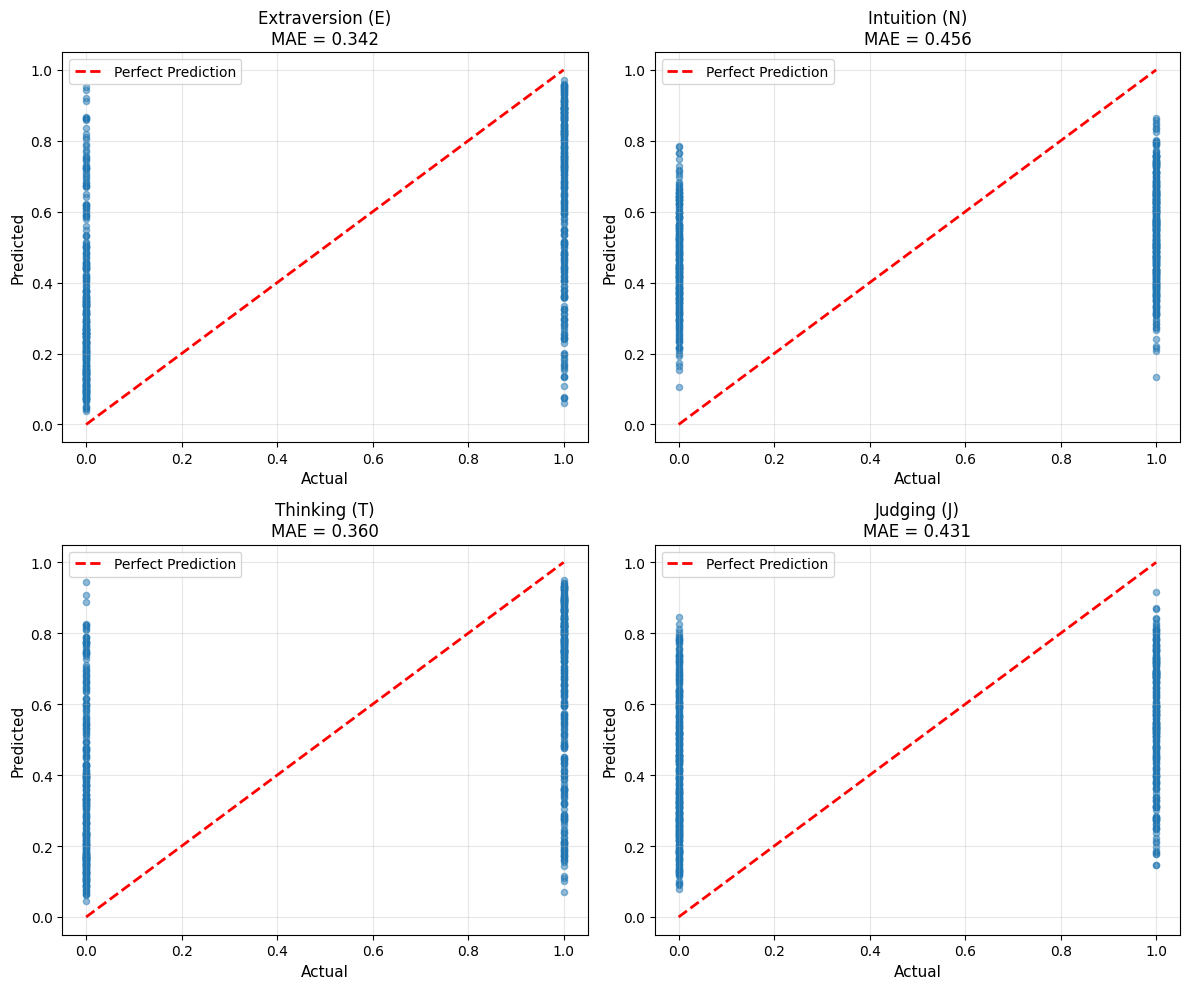

In [8]:
# 8: Predictions vs Actual Scatter Plot

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
dim_names = ['Extraversion (E)', 'Intuition (N)', 'Thinking (T)', 'Judging (J)']

for i, (name, ax) in enumerate(zip(dim_names, axes.flatten())):
    ax.scatter(targets[:, i], predictions[:, i], alpha=0.5, s=20)
    ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Prediction')
    ax.set_xlabel('Actual', fontsize=11)
    ax.set_ylabel('Predicted', fontsize=11)
    ax.set_title(f'{name}\nMAE = {results[dim_letters[i]]["mae"]:.3f}', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

SHAP EXPLAINABILITY ANALYSIS (KernelExplainer)
Background shape: (50, 45)
Test samples shape: (20, 45)
Creating KernelExplainer... (this takes ~10 seconds)
Calculating SHAP values for 5 test samples... (this takes 2-3 minutes)


  0%|          | 0/5 [00:00<?, ?it/s]

SHAP values shape: (5, 45, 4)

Feature Importance for Extraversion (E)


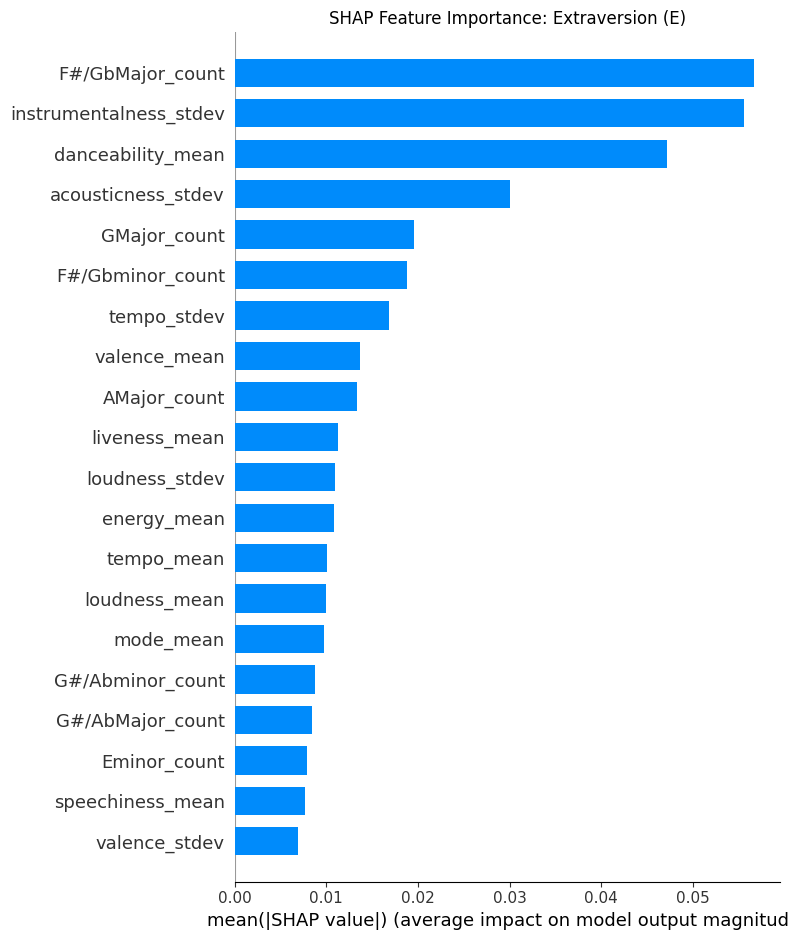

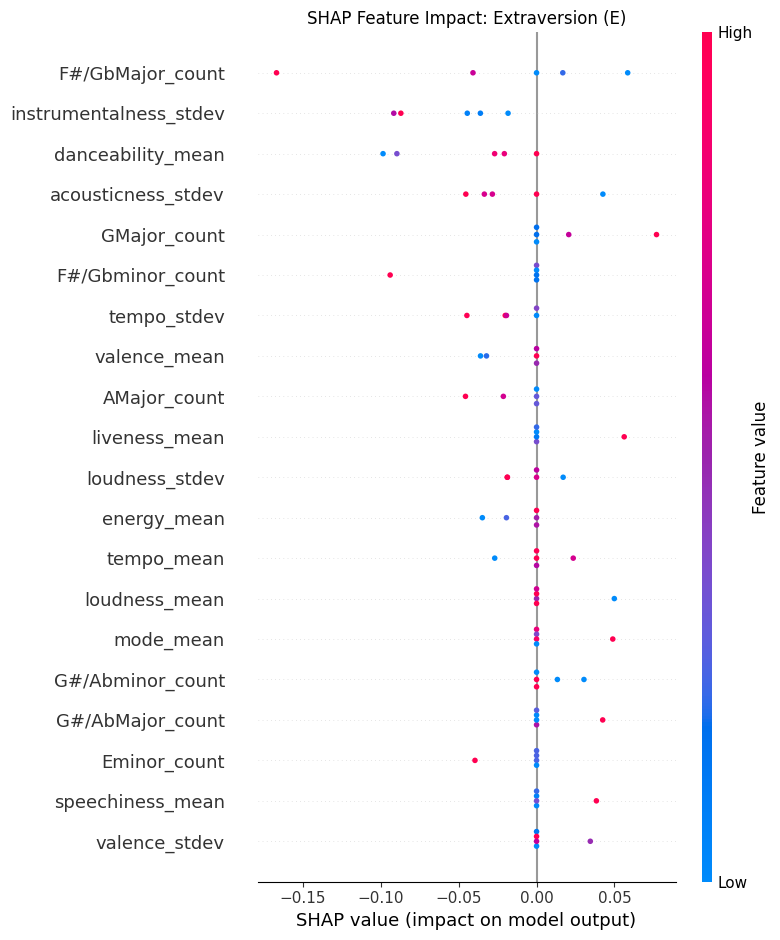


Feature Importance for Intuition (N)


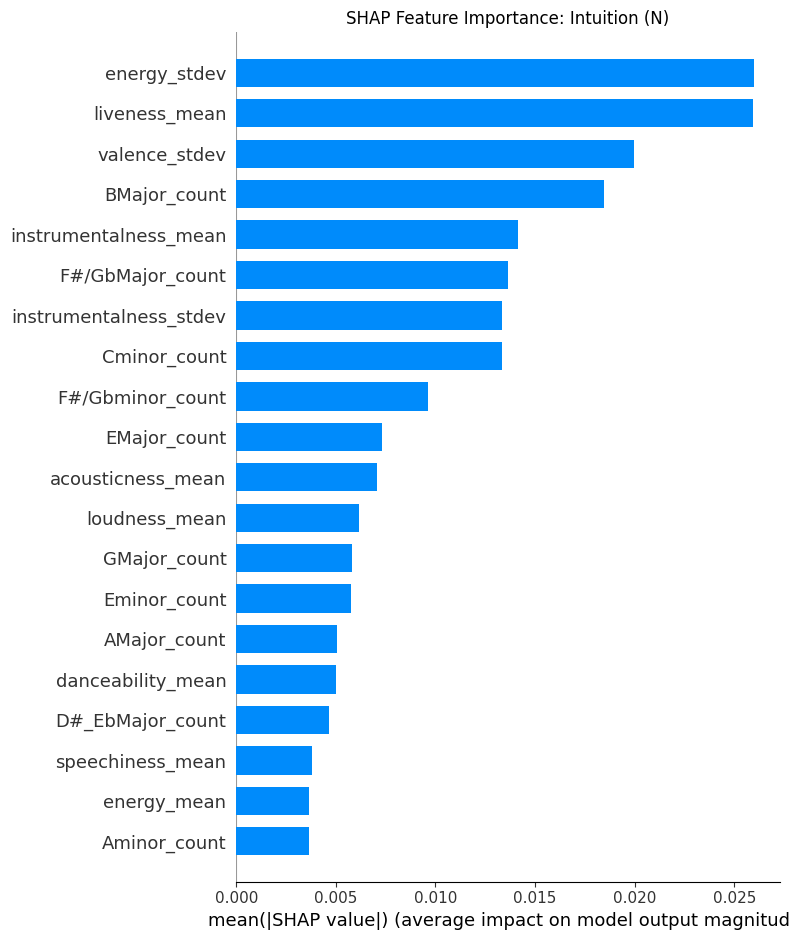

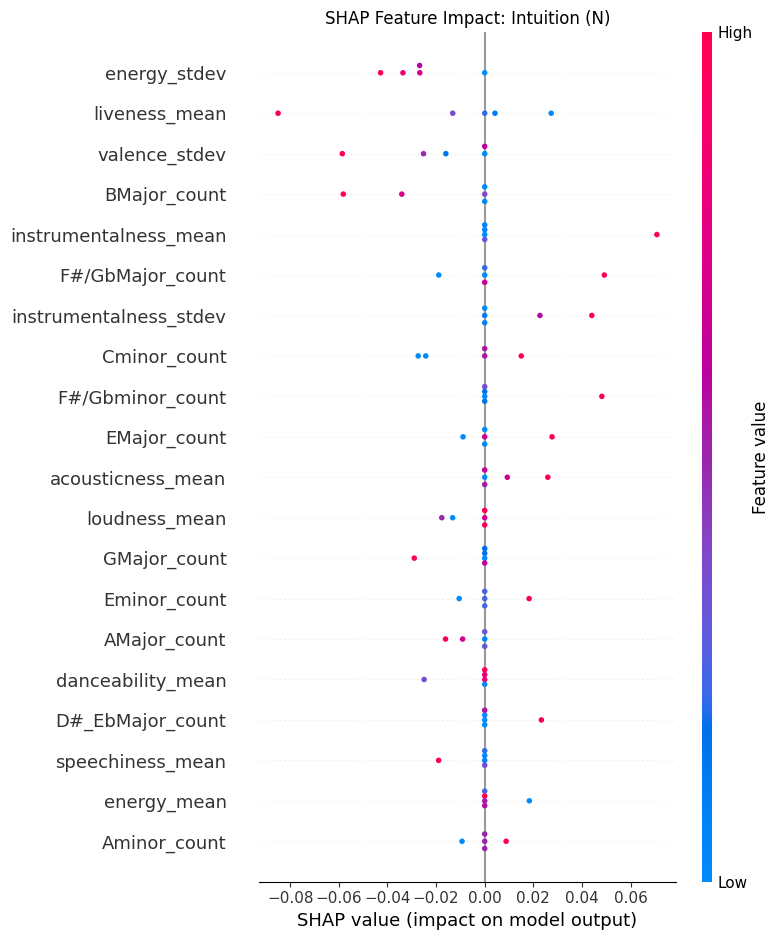


Feature Importance for Thinking (T)


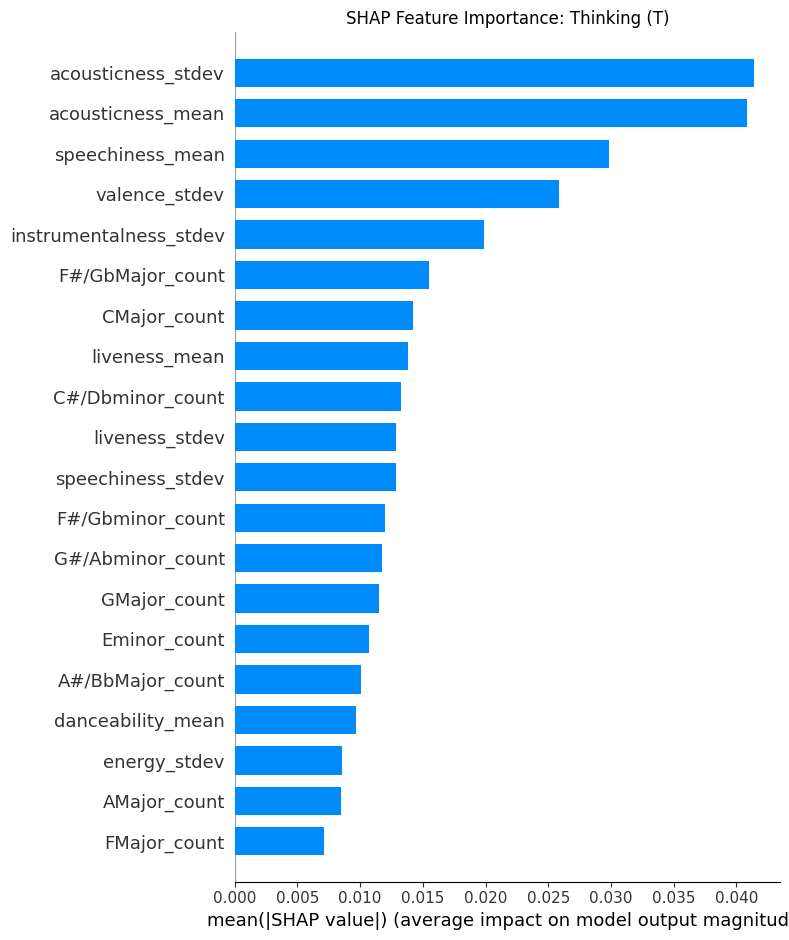

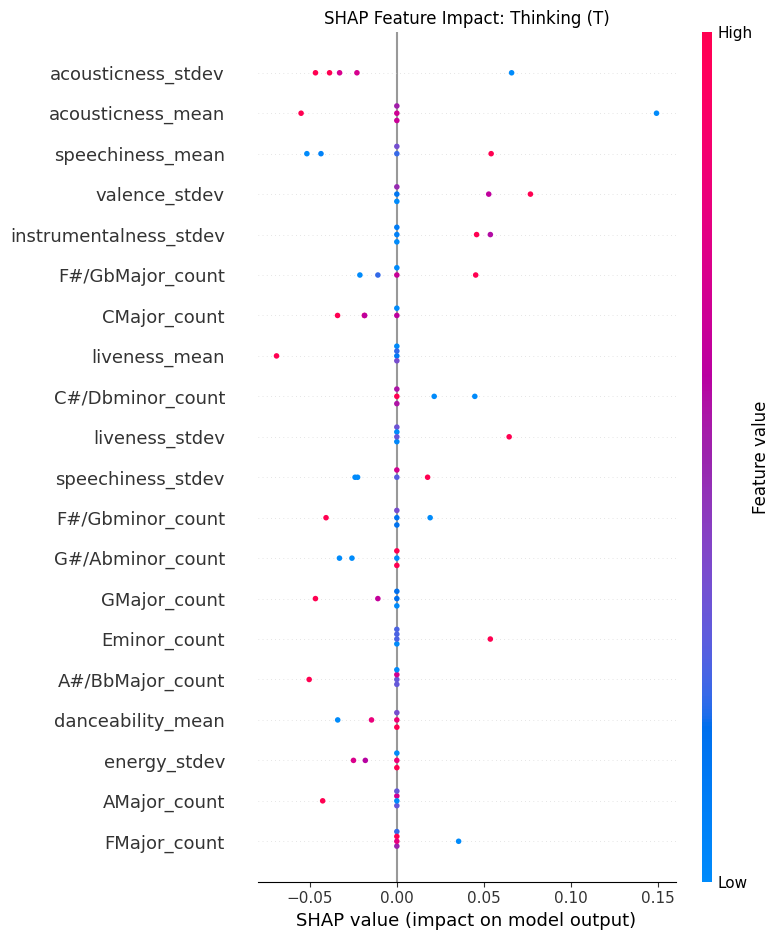


Feature Importance for Judging (J)


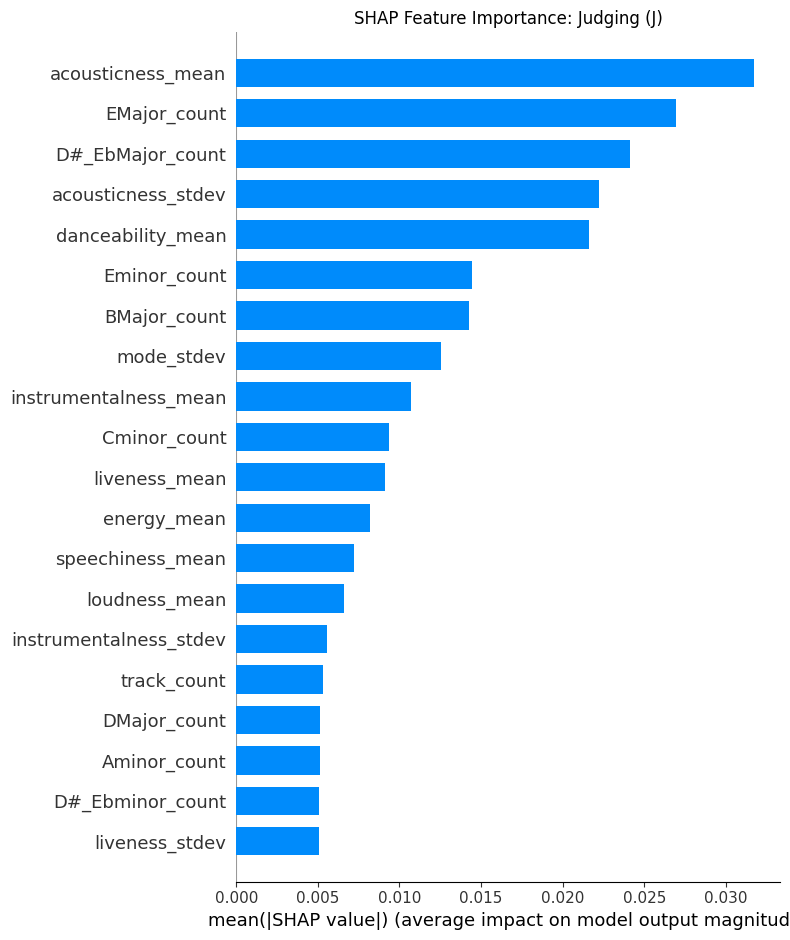

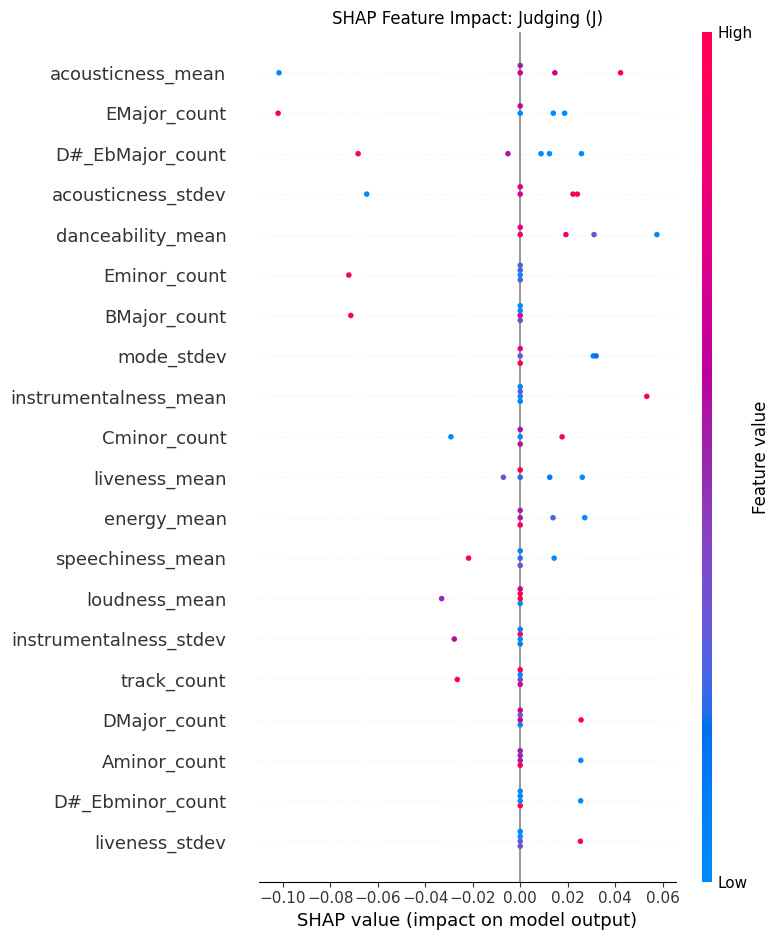


✅ SHAP Analysis Complete!
📁 Plots saved as PNG files

TOP 10 FEATURES PER DIMENSION (Mean |SHAP|)

Extraversion (E):
   F#/GbMajor_count              : 0.056662
   instrumentalness_stdev        : 0.055564
   danceability_mean             : 0.047197
   acousticness_stdev            : 0.029995
   GMajor_count                  : 0.019545
   F#/Gbminor_count              : 0.018812
   tempo_stdev                   : 0.016843
   valence_mean                  : 0.013636
   AMajor_count                  : 0.013398
   liveness_mean                 : 0.011262

Intuition (N):
   energy_stdev                  : 0.025989
   liveness_mean                 : 0.025941
   valence_stdev                 : 0.019947
   BMajor_count                  : 0.018451
   instrumentalness_mean         : 0.014162
   F#/GbMajor_count              : 0.013621
   instrumentalness_stdev        : 0.013352
   Cminor_count                  : 0.013327
   F#/Gbminor_count              : 0.009635
   EMajor_count               

In [9]:
# 9: SHAP

import shap
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("SHAP EXPLAINABILITY ANALYSIS (KernelExplainer)")
print("="*60)

# Move model to CPU
model_cpu = MBTINetwork(input_dim=X_train.shape[1])
model_cpu.load_state_dict(torch.load('/content/best_model.pth', map_location='cpu'))
model_cpu.eval()
model_cpu = model_cpu.to('cpu')

# Define prediction function for SHAP
def predict_proba(x):
    """Return raw logits for SHAP"""
    model_cpu.eval()
    with torch.no_grad():
        x_tensor = torch.tensor(x, dtype=torch.float32)
        outputs = model_cpu(x_tensor)
        return torch.sigmoid(outputs).numpy()

# Take background data (smaller subset for KernelExplainer speed)
background = X_train[:50].numpy()
test_samples = X_test[:20].numpy()

print(f"Background shape: {background.shape}")
print(f"Test samples shape: {test_samples.shape}")

# Create KernelExplainer
print("Creating KernelExplainer... (this takes ~10 seconds)")
explainer = shap.KernelExplainer(predict_proba, background)

# Calculate SHAP values
print("Calculating SHAP values for 5 test samples... (this takes 2-3 minutes)")
n_samples_to_explain = min(5, len(test_samples))
shap_values = explainer.shap_values(test_samples[:n_samples_to_explain])

# shap_values is a 3D numpy array of shape (n_samples, n_features, n_outputs)
print(f"SHAP values shape: {shap_values.shape}")

feature_names_list = feature_cols if isinstance(feature_cols, list) else feature_cols.tolist()
dim_names = ['Extraversion (E)', 'Intuition (N)', 'Thinking (T)', 'Judging (J)']

# Generate plots for each dimension
for i, name in enumerate(dim_names):
    if i < shap_values.shape[2]:  # Ensure we don't exceed output dimensions
        current_shap_values = shap_values[:, :, i]  # Shape: (n_samples, n_features)

        print(f"\n{'='*40}")
        print(f"Feature Importance for {name}")
        print(f"{'='*40}")

        # Bar plot
        shap.summary_plot(
            current_shap_values,
            test_samples[:n_samples_to_explain],
            feature_names=feature_names_list,
            plot_type="bar",
            show=False,
            max_display=20
        )
        plt.title(f"SHAP Feature Importance: {name}", fontsize=12)
        plt.tight_layout()
        plt.savefig(f"shap_summary_{dim_names[i][0]}.png", dpi=150, bbox_inches='tight')
        plt.show()

        # Dot plot (more detailed)
        shap.summary_plot(
            current_shap_values,
            test_samples[:n_samples_to_explain],
            feature_names=feature_names_list,
            show=False,
            max_display=20
        )
        plt.title(f"SHAP Feature Impact: {name}", fontsize=12)
        plt.tight_layout()
        plt.savefig(f"shap_dot_{dim_names[i][0]}.png", dpi=150, bbox_inches='tight')
        plt.show()

print("\n" + "="*60)
print("✅ SHAP Analysis Complete!")
print("📁 Plots saved as PNG files")
print("="*60)

# Print top features for each dimension
print("\n" + "="*60)
print("TOP 10 FEATURES PER DIMENSION (Mean |SHAP|)")
print("="*60)

for i, name in enumerate(dim_names):
    if i < shap_values.shape[2]:
        current_shap = shap_values[:, :, i]
        mean_shap = np.abs(current_shap).mean(axis=0)
        top_indices = np.argsort(mean_shap)[-10:][::-1]

        print(f"\n{name}:")
        for idx in top_indices:
            print(f"   {feature_names_list[idx]:30s}: {mean_shap[idx]:.6f}")